# Seaborn을 이용한 주요 시각화 그래프

- Seaborn 공식 사이트 : https://seaborn.pydata.org/tutorial.html
- Matplotlib 기반으로 쉽게 작성됨. Matplotlib의 high level API
- Matplotlib 보다 수려한 디자인을 제공하며 Pandas와 쉽게 연동
- 그러나 Matplotlib을 어느 정도 알고 있어야함

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

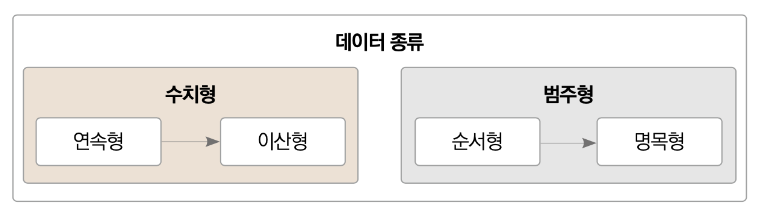

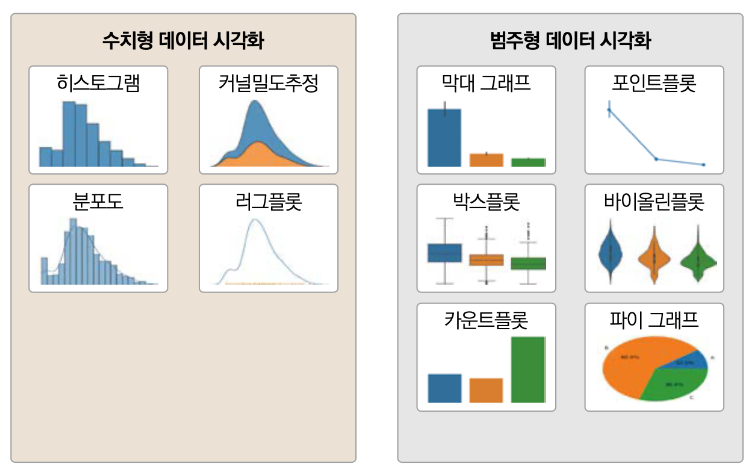

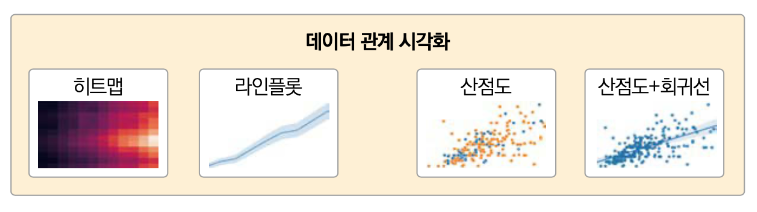

In [ ]:
tips = pd.read_csv('./data/tips.csv')
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


## 1. 수치형 데이터 시각화

### 1. 히스토그램
- 수치형 데이터의 구간별 빈도수를 나타내는 그래프

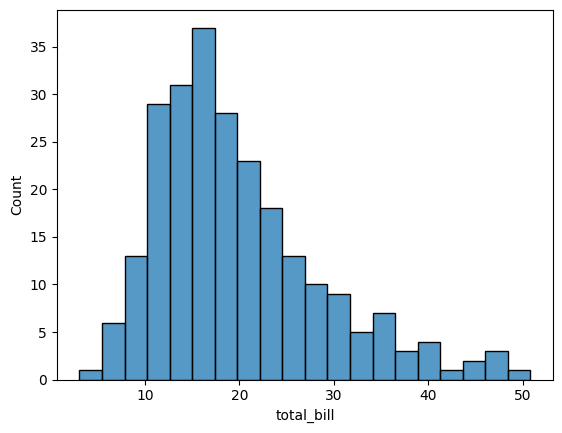

In [ ]:
sns.histplot(data=tips, x='total_bill', bins=20)
plt.show()

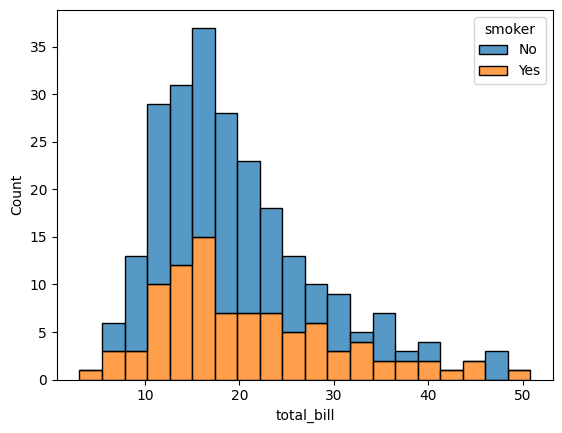

In [ ]:
# 정보 쪼개기(break-down) : total_bill의 히스토그램을 smoker/non-smoker 그룹으로 분할
sns.histplot(data=tips, x='total_bill', bins=20, hue='smoker',
             multiple='stack')
plt.show()

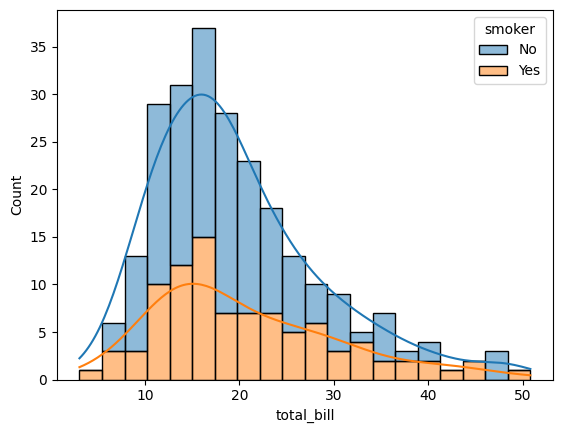

In [ ]:
sns.histplot(data=tips, x='total_bill', bins=20, hue='smoker',
             multiple='stack', kde=True)
plt.show()

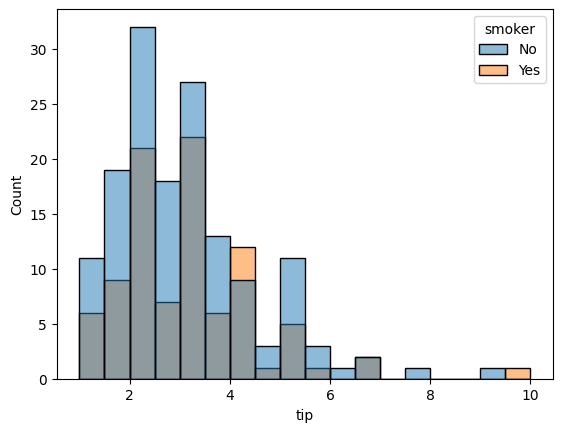

In [ ]:
sns.histplot(data=tips, x='tip', hue='smoker')
plt.show()

### 2. 커널밀도추정 함수

- 히스토그램을 매끄럽게 곡선으로 연결한 그래프

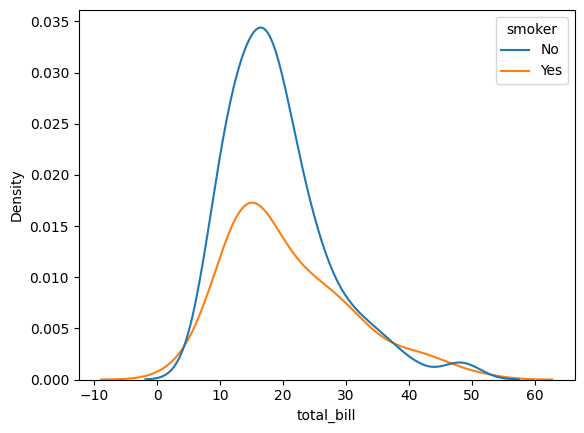

In [ ]:
sns.kdeplot(data=tips, x='total_bill', hue='smoker')
plt.show()

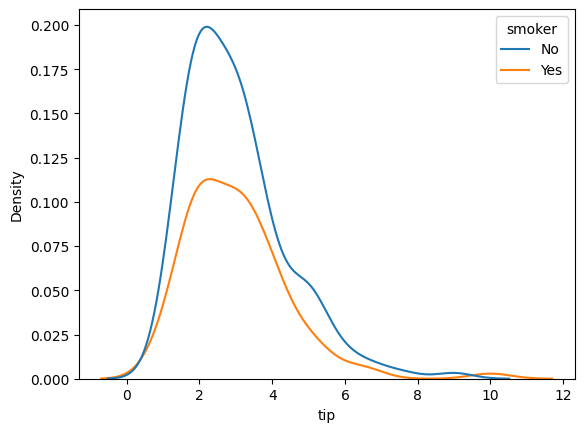

In [ ]:
sns.kdeplot(data=tips, x='tip', hue='smoker')
plt.show()

- Figure-level vs. axes-level

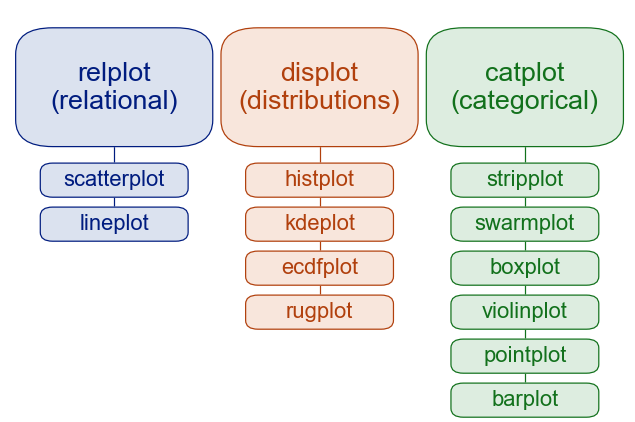

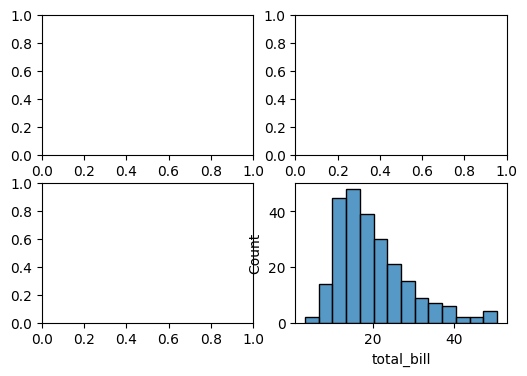

In [ ]:
# sns.histplot() 함수는 plt의 figure, axes 가 연계
# plt.figure(figsize=(4, 3))
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 4))
sns.histplot(data=tips, x='total_bill', ax=axes[1, 1])
plt.show()

<Figure size 400x300 with 0 Axes>

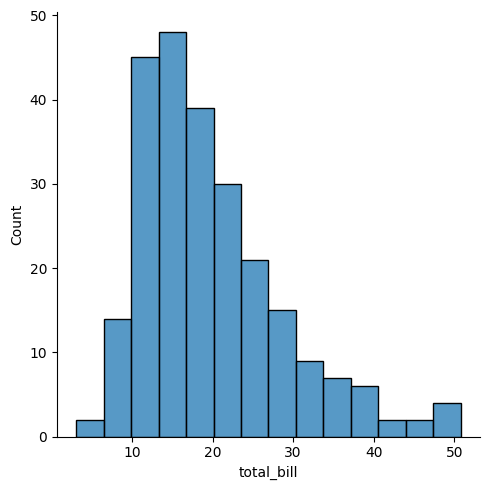

In [ ]:
# sns.displot() 함수는 plt의 figure, axes 가 연계가 되지 않음
plt.figure(figsize=(4, 3))
sns.displot(data=tips, x='total_bill')
plt.show()

<Axes: ylabel='total_bill'>

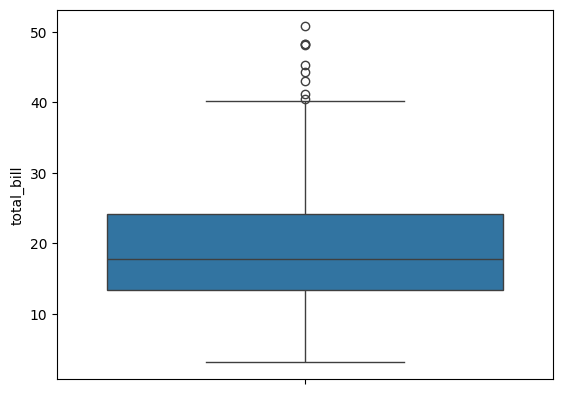

In [ ]:
# histogram 만으로도 데이터 분포를 볼 수 있지만
# boxplot도 함께 그리면 바깥값(outlier)도 확인할 수 있음
sns.boxplot(data=tips, y='total_bill')

## 2. 범주형 데이터 시각화

### (1) 막대그래프(barplot)
- 범주형 데이터 값에 따라 수치형 데이터 값이 어떻게 달라지는지 파악할 때 사용
- 범주형 데이터에 따른 수치형 데이터의 평균과 신뢰구간을 그려줌
- 수치형 데이터 평균은 막대높이로, 신뢰구간은 오차 막대로 표현함

In [ ]:
tips.columns

Index(['total_bill', 'tip', 'smoker', 'day', 'time', 'size'], dtype='object')

<Axes: xlabel='time', ylabel='tip'>

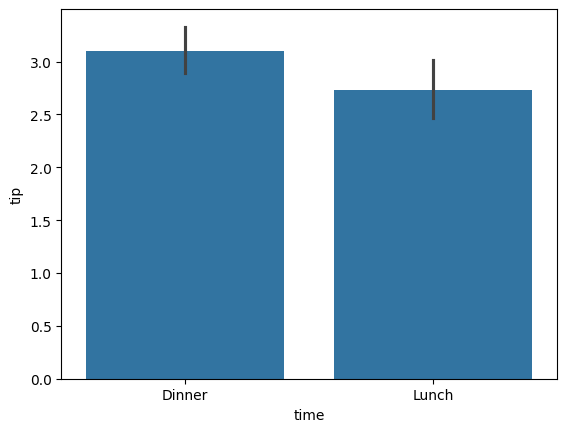

In [ ]:
# time : 범주형, tip : 수치형
sns.barplot(data=tips, x='time', y='tip')
plt.show()

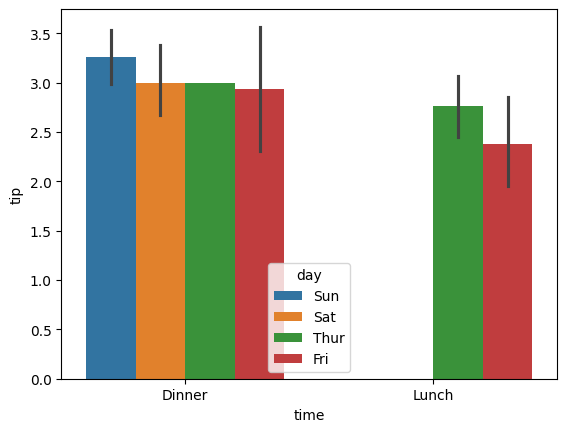

In [ ]:
sns.barplot(data=tips, x='time', y='tip', hue='day')
plt.show()

### (2) 포인트 플롯(pointplot)
- 막대 그래프와 모양만 다를 뿐 동일한 정보 제공
- 막대 그래프와 마찬가지로 범주형 데이터에 따른 수치형 데이터의 평균과 신뢰구간을 나타냄
- 다만 그래프를 점과 선으로 나타냄

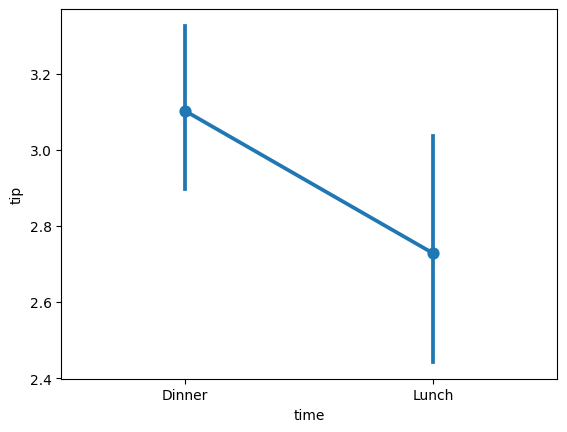

In [ ]:
sns.pointplot(data=tips, x='time', y='tip')
plt.show()

### (3) 박스플롯(boxplot)
- 막대그래프나 포인트플롯보다 더 많은 정보를 제공
- 5가지 요약 수치 : 최솟값, 1사분위수(Q1), 2사분위수(Q2), 3사분위수(Q3), 최댓값

- 1사분위수(Q1) : 전체 데이터 중 하위 25%에 해당하는 값
- 2사분위수(Q2): 50%에 해당하는 값
- 3사분위수(Q3) : 상위 25%에 해당하는 값
- 사분위 범위수(IQR) : Q3 - Q1
- 최댓값(Max) : Q3 + (1.5 * IQR)
- 최솟값(Min) : Q1 - (1.5 * IQR)

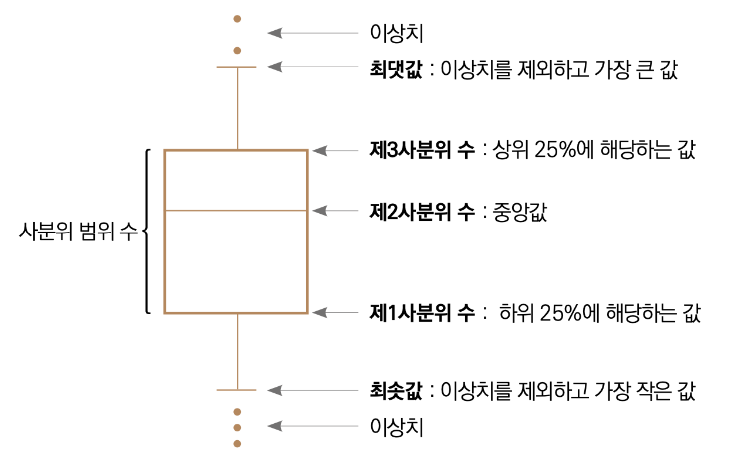

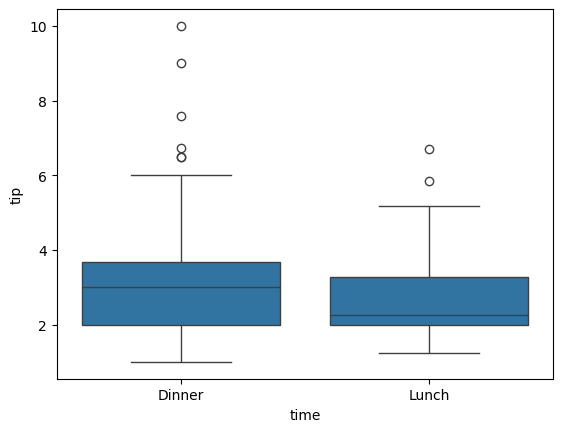

In [ ]:
sns.boxplot(data=tips, x='time', y='tip')
plt.show()

<Axes: ylabel='tip'>

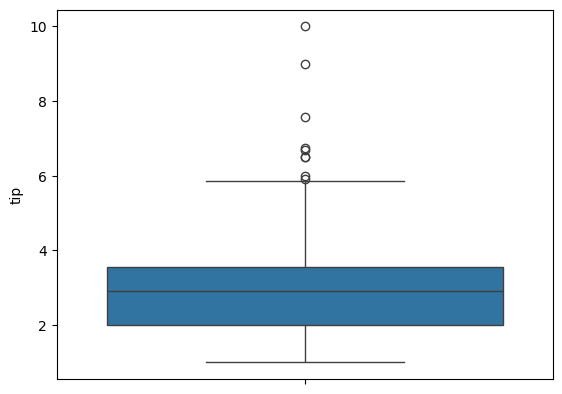

In [ ]:
# 범주를 나누지 않고 tip에 대해서만 사분위수 분포 보기
sns.boxplot(data=tips, y='tip')

### (4) 바이올린플롯(violinplot)
- 박스플롯과 커널밀도추정 함수 그래프를 합쳐 놓은 그래프
- 박스플롯에 제공하는 정보를 모두 포함하며, 모양은 커널밀도추정 함수 그래프 형태임

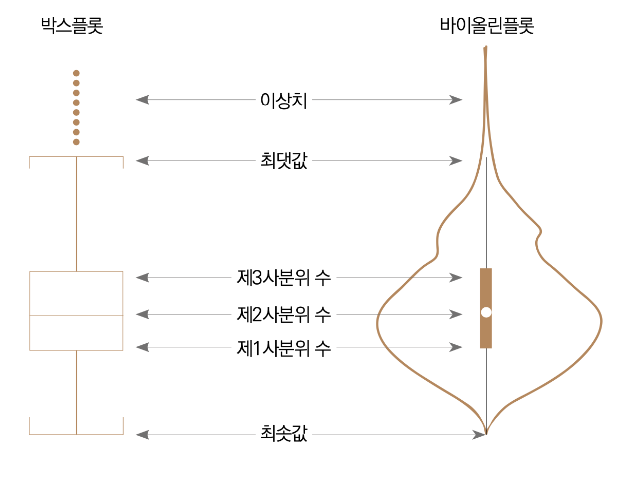

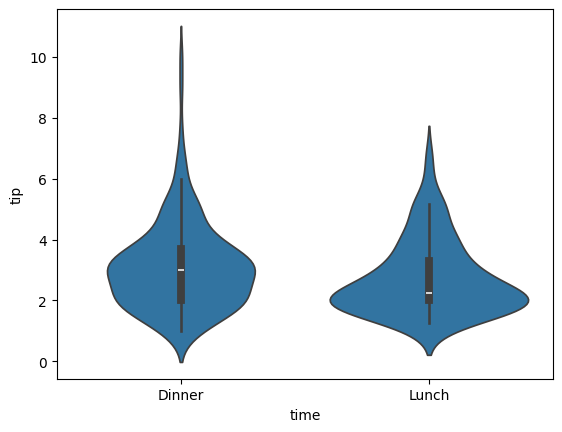

In [ ]:
sns.violinplot(data=tips, x='time', y='tip')
plt.show()

### (5) 카운트플롯(countplot)
- 카운트플롯은 범주형 데이터의 개수를 확인할 때 사용하는 그래프
- 주로 범주형 피처나 범주형 타깃값의 분포가 어떤지 파악하는 용도로 사용
- 카운트플롯을 사용하면 범주형 데이터의 개수를 파악할 수 있음


In [ ]:
tips.columns

Index(['total_bill', 'tip', 'smoker', 'day', 'time', 'size'], dtype='object')

In [ ]:
data = tips['day'].value_counts()
data

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


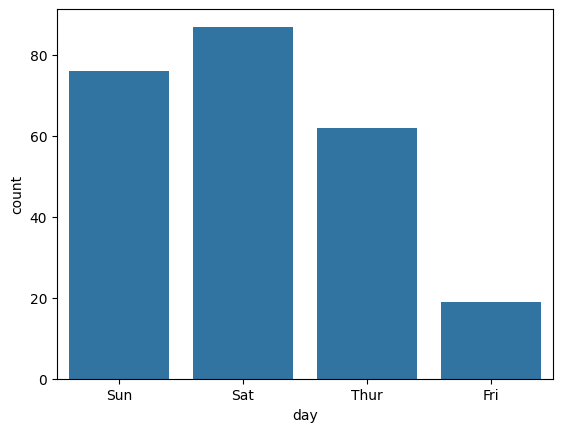

In [ ]:
sns.countplot(data=tips, x='day') # tips['day'].value_counts()와 동일한 정보
plt.show()

### (6) 파이 그래프(pie)
- 범주형 데이터별 비율을 알아볼 때 사용하기 좋은 그래프
- seaborn에서 파이 그래프를 지원하지 않아 matplotlib을 사용

In [ ]:
tips['day'].value_counts(normalize=True)

,proportion
day,
Sat,0.356557
Sun,0.311475
Thur,0.254098
Fri,0.077869


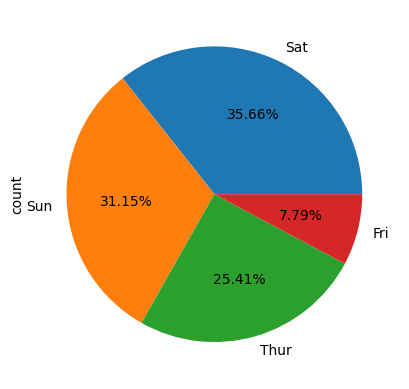

In [ ]:
# 시리즈.plot(kind=XXX)
data.plot(kind='pie', autopct='%.2f%%')
plt.show()

## 3. 데이터 관계 시각화


### (1) 산점도(scatterplot)
- 산점도는 두 데이터의 관계를 점으로 표현하는 그래프

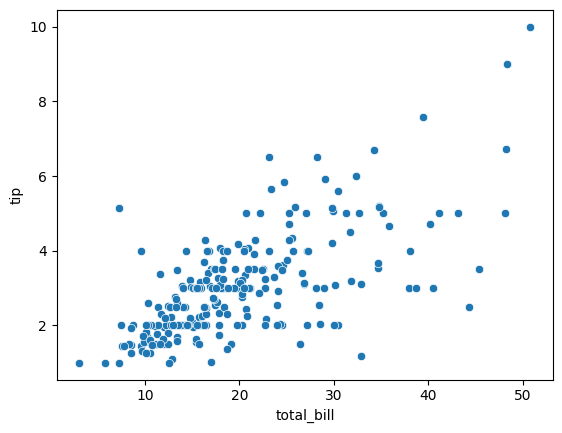

In [ ]:
# total_bill과 tip의 산점도
sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.show()

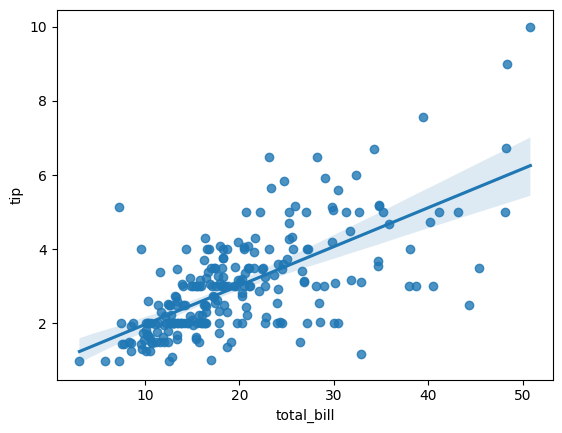

In [ ]:
sns.regplot(data=tips, x='total_bill', y='tip')
plt.show()

In [ ]:
tips[['total_bill', 'tip']].corr() # 0.67 정도의 양의 상관관계

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


In [ ]:
tips.columns

Index(['total_bill', 'tip', 'smoker', 'day', 'time', 'size'], dtype='object')

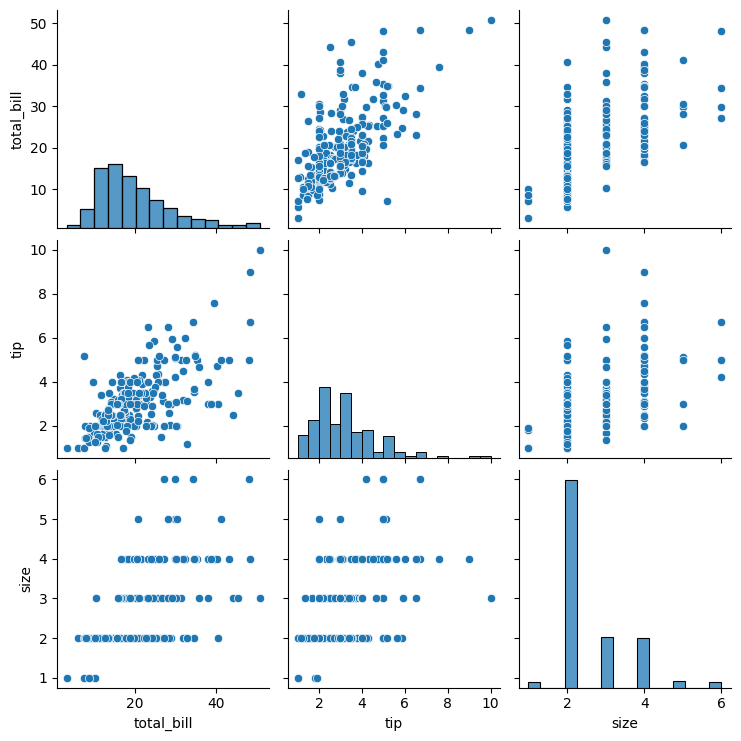

In [ ]:
numeric_data = tips[['total_bill', 'tip', 'size']]
sns.pairplot(numeric_data)
plt.show()

### (2) 히트맵(heatmap)
- 데이터 간 관계를 색상으로 표현한 그래프
- 비교해야 할 데이터가 많을 때 주로 사용

In [ ]:
corr = numeric_data.corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


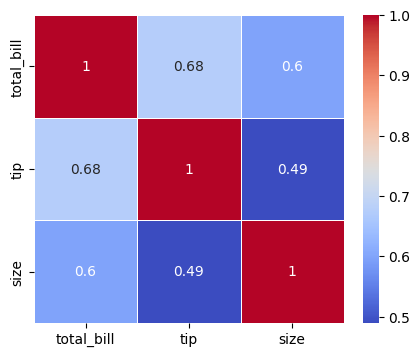

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidth=0.5)
plt.show()

* [컬러맵 정보](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

## 4. 실습

**seaborn에서 subplots(axes) 이용하기**

**(a) subplots(axes)을 이용하여 주요 범주형 데이터의 건수를 시각화 하세요**

In [ ]:
tips.columns

Index(['total_bill', 'tip', 'smoker', 'day', 'time', 'size'], dtype='object')

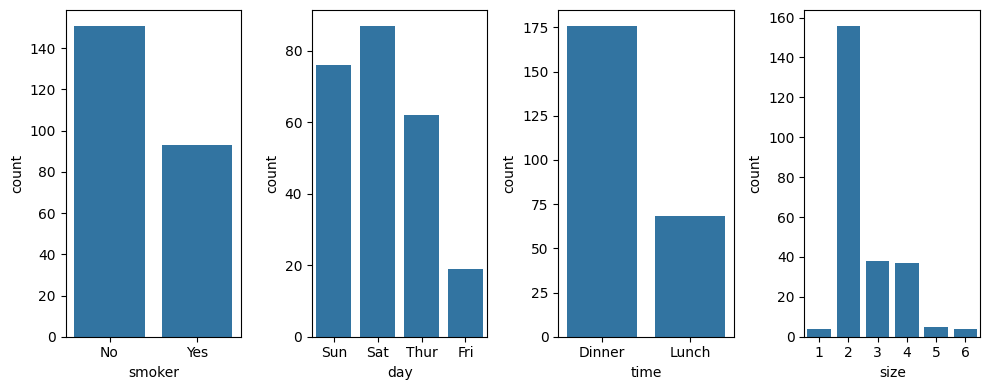

In [ ]:
# todo

cat_columns = ['smoker', 'day', 'time', 'size']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 4))

for i, column in enumerate(cat_columns):
    sns.countplot(data=tips, x=column, ax=axes[i])


plt.tight_layout()
plt.show()


**(b) subplots(axes)을 이용하여 주요 범주형 데이터별 수치형 데이터(예. total_bill)의 평균값을 시각화 하세요**

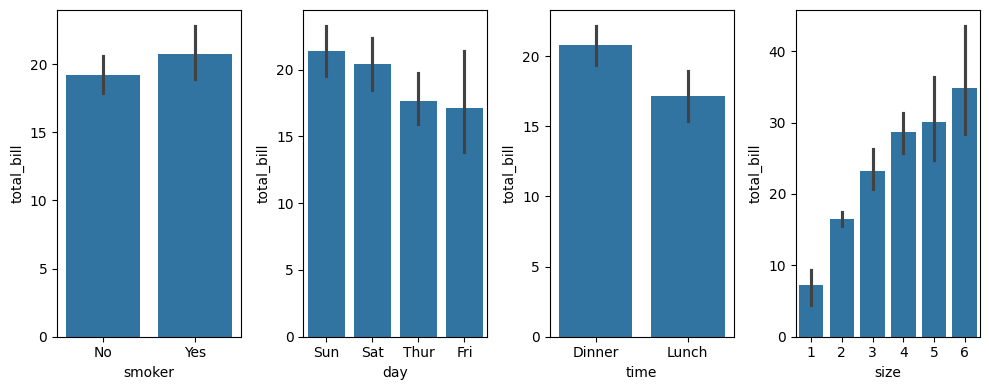

In [ ]:
# todo

cat_columns = ['smoker', 'day', 'time', 'size']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 4))

for i, column in enumerate(cat_columns):
    sns.barplot(data=tips, x=column, y='total_bill', ax=axes[i])

plt.tight_layout()
plt.show()